# Pruebas del modelo final: evaluación y explicabilidad (SHAP)

Este notebook carga el modelo ya entrenado (`modelo/pipeline_churn.pkl`) y responde tres preguntas:

1. **¿Qué tan bien predice** sobre clientes que no vio durante el entrenamiento?
2. **¿Funciona con un cliente nuevo**, con los datos tal como llegarían en producción?
3. **¿Por qué predice lo que predice?** Con SHAP se explica el modelo en general y cada predicción en particular.

In [1]:
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Las clases deben estar importadas para que joblib pueda reconstruir el pipeline
sys.path.append("../modelo")
from transformadores import LimpiarTotalCharges, EliminarColumnas, CrearCantidadServicios, MapearBinarias

pipeline_final = joblib.load("../modelo/pipeline_churn.pkl")
print([nombre for nombre, _ in pipeline_final.steps])
print(type(pipeline_final.named_steps["modelo"]).__name__)

['limpiar_totalcharges', 'eliminar_columnas', 'crear_cantidad_servicios', 'mapear_binarias', 'encoding_nominales', 'modelo']
RandomForestClassifier


## 1. Evaluación en el conjunto de prueba

Se reproduce la misma partición usada al entrenar (`random_state=42`), de modo que estos 1.409 clientes son nuevos para el modelo.

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_test.shape)

(1409, 20)


In [3]:
predicciones = pipeline_final.predict(X_test)
probabilidades = pipeline_final.predict_proba(X_test)

print(classification_report(y_test, predicciones, target_names=["No cancela", "Cancela"]))
print(f"ROC-AUC: {roc_auc_score(y_test, probabilidades[:, 1]):.3f}")

              precision    recall  f1-score   support

  No cancela       0.90      0.76      0.83      1035
     Cancela       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.842


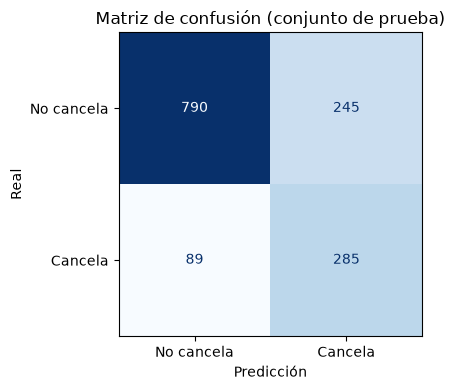

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones, display_labels=["No cancela", "Cancela"],
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set(title="Matriz de confusión (conjunto de prueba)", xlabel="Predicción", ylabel="Real")
plt.tight_layout()
plt.show()

## 2. Predicción para un cliente nuevo

Un cliente con contrato mes a mes, fibra óptica y cinco meses de antigüedad. Los datos se entregan crudos (incluido `TotalCharges` como texto) y el pipeline se encarga del resto.

In [5]:
cliente_nuevo = pd.DataFrame({
    "customerID": ["0000-TEST"],
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [80.0],
    "TotalCharges": ["400.5"],
})

prediccion = pipeline_final.predict(cliente_nuevo)
probabilidad = pipeline_final.predict_proba(cliente_nuevo)

print("Predicción:", "Cancela" if prediccion[0] == 1 else "No cancela")
print(f"Riesgo estimado de cancelar: {probabilidad[0][1]:.2%}")

Predicción: Cancela
Riesgo estimado de cancelar: 89.70%


## 3. Explicabilidad con SHAP

SHAP reparte cada predicción entre las variables: cuánto sube o baja el riesgo estimado por cada característica del cliente, respecto al promedio del modelo.

SHAP trabaja sobre el modelo, no sobre el pipeline completo. Por eso primero se pasan los datos por los pasos de preprocesamiento y después se explica el Random Forest.

In [6]:
# 1. El modelo es el último paso del pipeline
modelo = pipeline_final.named_steps["modelo"]

# 2. Los pasos anteriores transforman X_test al formato que recibe el modelo
pasos_preprocesamiento = pipeline_final[:-1]
X_test_transformado = pasos_preprocesamiento.transform(X_test)

# 3. Nombres de las columnas, sin el prefijo que añade ColumnTransformer
nombres_columnas = [
    nombre.split("__", 1)[1]
    for nombre in pipeline_final.named_steps["encoding_nominales"].get_feature_names_out()
]

print(X_test_transformado.shape)
print(nombres_columnas)

(1409, 17)
['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'cantidad_servicios']


In [7]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test_transformado)

# Una matriz por cliente, variable y clase. Se usa la clase 1 ("Cancela")
print(shap_values.shape)
shap_cancela = shap_values[:, :, 1]

(1409, 17, 2)


### 3.1 Visión global: qué variables pesan más

Cada punto es un cliente. La posición horizontal indica si esa variable le sube (derecha) o le baja (izquierda) el riesgo; el color, si el valor de la variable es alto (rojo) o bajo (azul).

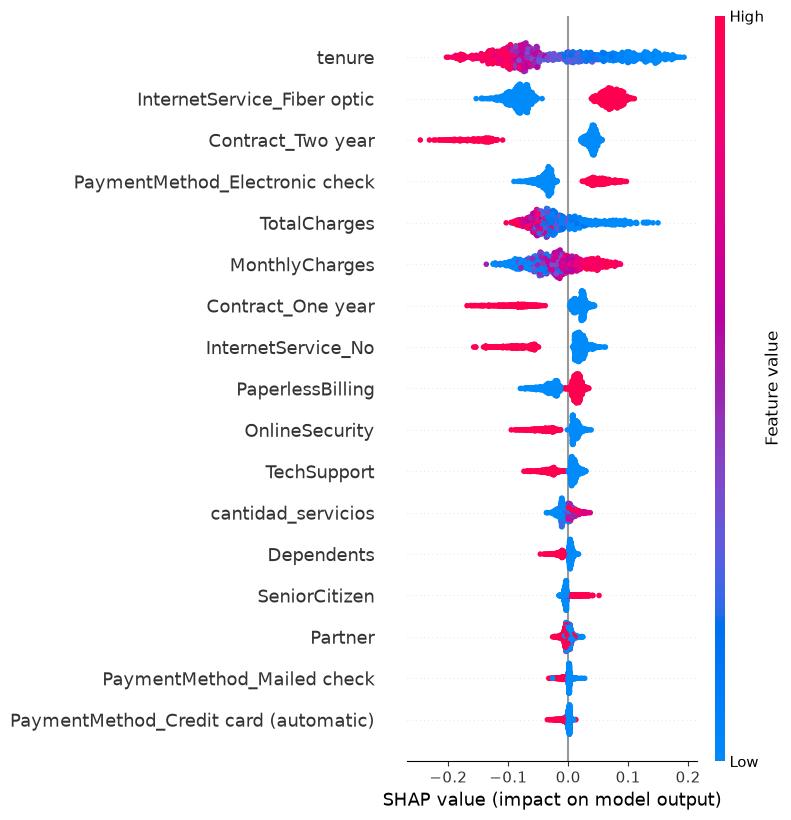

In [8]:
shap.summary_plot(shap_cancela, X_test_transformado, feature_names=nombres_columnas, show=False)
plt.tight_layout()
plt.savefig("../img/shap_resumen.png", dpi=150, facecolor="white", bbox_inches="tight")
plt.show()

In [9]:
# Importancia global: promedio del valor absoluto de SHAP por variable
importancia = pd.Series(np.abs(shap_cancela).mean(axis=0), index=nombres_columnas).sort_values(ascending=False)
importancia.round(3).head(8)

tenure                            0.086
InternetService_Fiber optic       0.078
Contract_Two year                 0.066
PaymentMethod_Electronic check    0.043
TotalCharges                      0.041
MonthlyCharges                    0.039
Contract_One year                 0.035
InternetService_No                0.035
dtype: float64

### 3.2 Explicación de un cliente de alto riesgo

El cliente del conjunto de prueba con mayor riesgo estimado.

In [10]:
indice_alto_riesgo = probabilidades[:, 1].argmax()

print("Predicción:", "Cancela" if predicciones[indice_alto_riesgo] == 1 else "No cancela")
print(f"Riesgo estimado de cancelar: {probabilidades[indice_alto_riesgo][1]:.2%}")
print("Qué pasó en realidad:", "canceló" if y_test.iloc[indice_alto_riesgo] == 1 else "no canceló")

Predicción: Cancela
Riesgo estimado de cancelar: 98.29%
Qué pasó en realidad: canceló


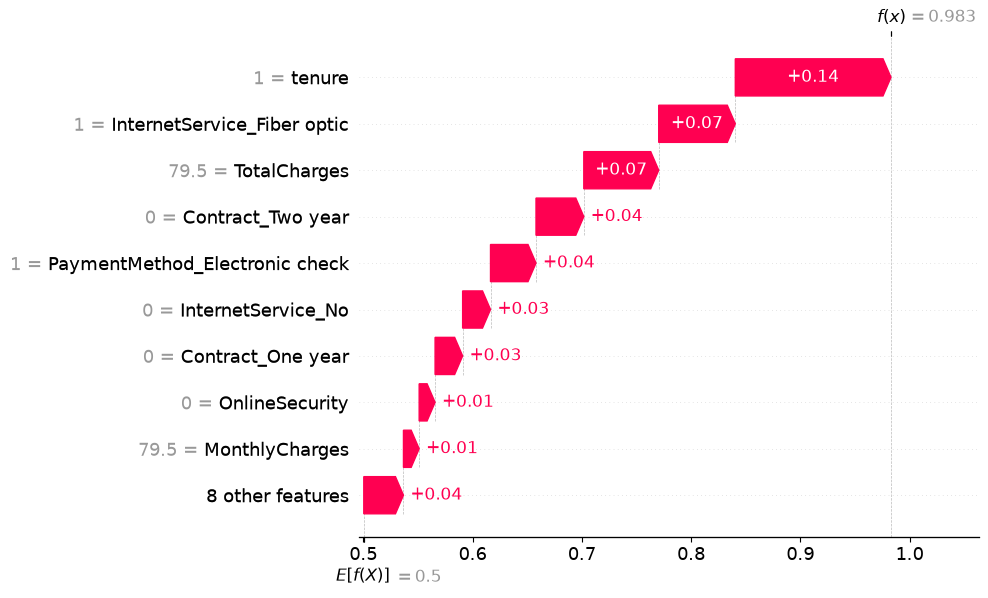

In [11]:
explicacion_alto_riesgo = shap.Explanation(
    values=shap_cancela[indice_alto_riesgo],          # valores SHAP de este cliente para la clase "Cancela"
    base_values=explainer.expected_value[1],          # valor base del modelo (promedio general)
    data=X_test_transformado[indice_alto_riesgo],     # valores reales de este cliente
    feature_names=nombres_columnas,
)

shap.plots.waterfall(explicacion_alto_riesgo, show=False)
plt.savefig("../img/shap_cliente_alto_riesgo.png", dpi=150, facecolor="white", bbox_inches="tight")
plt.show()

### 3.3 Explicación de un cliente de bajo riesgo

El cliente del conjunto de prueba con menor riesgo estimado.

In [12]:
indice_bajo_riesgo = probabilidades[:, 1].argmin()

print("Predicción:", "Cancela" if predicciones[indice_bajo_riesgo] == 1 else "No cancela")
print(f"Riesgo estimado de cancelar: {probabilidades[indice_bajo_riesgo][1]:.2%}")
print("Qué pasó en realidad:", "canceló" if y_test.iloc[indice_bajo_riesgo] == 1 else "no canceló")

Predicción: No cancela
Riesgo estimado de cancelar: 0.05%
Qué pasó en realidad: no canceló


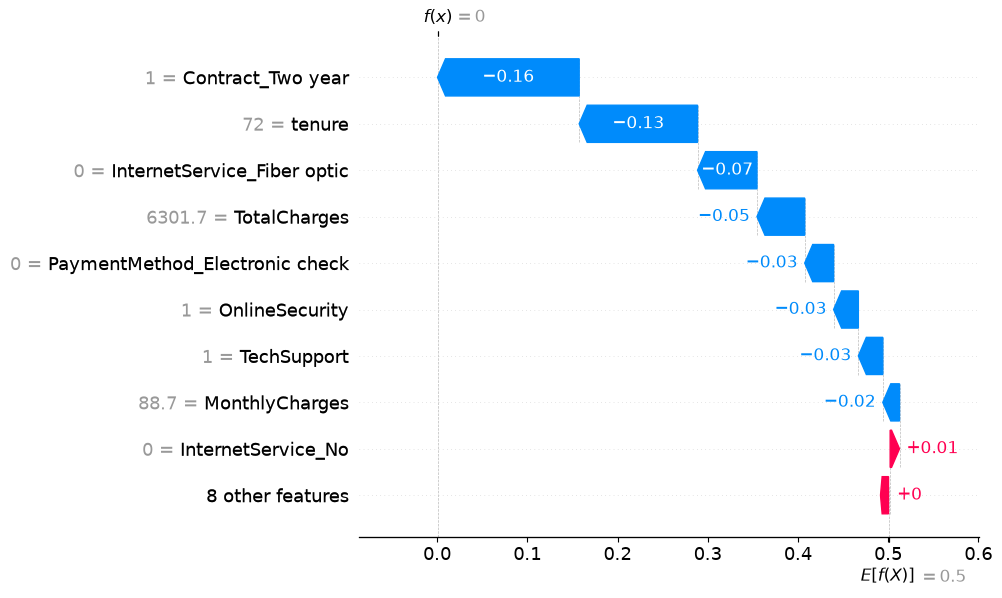

In [13]:
explicacion_bajo_riesgo = shap.Explanation(
    values=shap_cancela[indice_bajo_riesgo],
    base_values=explainer.expected_value[1],
    data=X_test_transformado[indice_bajo_riesgo],
    feature_names=nombres_columnas,
)

shap.plots.waterfall(explicacion_bajo_riesgo)

## Conclusiones

- **Rendimiento.** Sobre clientes que no había visto, el modelo detecta 285 de las 374 cancelaciones (recall 0,76) con una precisión de 0,54 y un ROC-AUC de 0,842.
- **Funciona con datos crudos.** El pipeline recibe un cliente nuevo tal como llegaría del sistema de origen y devuelve la predicción, sin pasos manuales.
- **Variables con más peso.** La antigüedad es la más influyente: los clientes recientes tienen más riesgo. Le siguen el internet por fibra óptica y el pago con cheque electrónico, que suben el riesgo, y el contrato de dos años, que lo baja. Coincide con lo observado en el EDA.
- **Predicciones explicables una a una.** El cliente de mayor riesgo (98 %) lleva un mes en la empresa, tiene fibra óptica, contrato mes a mes y paga con cheque electrónico. El de menor riesgo lleva 72 meses, con contrato de dos años y sin fibra óptica.

**Sobre los porcentajes.** El modelo se entrenó dando el mismo peso a las dos clases, por eso el valor base de SHAP es 0,5 y no el 26,5 % real de cancelación. Los porcentajes sirven para ordenar y comparar clientes, pero no son probabilidades calibradas.